# Sesi 12 - Decision Tree

Decision Tree adalah model ML yang membuat keputusan lewat serangkaian pertanyaan ya/tidak, mirip seperto flowchart
kelebihan decision tree yaitu mudah dijelaskan dan divisualisasikan

Kita akan membuat model untuk memprediksi apakah sebuah transaksi akan untung atau rugi

## 1. Persiapan Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("samplesuperstore.csv", encoding="latin1")

In [8]:
# Buat target: 1 = untung, 0 = rugi
df["Untung"] = (df["Profit"] > 0).astype(int)

X = df[["Sales", "Discount", "Quantity"]]
y = df["Untung"]

print(df[["Sales", "Discount", "Quantity", "Profit", "Untung"]].head())
print("\nDistribusi target:")
print(y.value_counts())

     Sales  Discount  Quantity   Profit  Untung
0   16.448       0.2         2   5.5512       1
1    3.540       0.8         2  -5.4870       0
2   11.784       0.2         3   4.2717       1
3  272.736       0.2         3 -64.7748       0
4   19.536       0.2         3   4.8840       1

Distribusi target:
Untung
1    8228
0    1966
Name: count, dtype: int64


## 2. Split Data & Training Model

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth dibatasi biar pohon tidak terlalu kompleks
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model selesai di-training")
print(f"Data training: {X_train.shape[0]} baris")
print(f"Data testing: {X_test.shape[0]} baris")

Model selesai di-training
Data training: 8155 baris
Data testing: 2039 baris


## 3. Evaluasi Model

In [14]:
y_pred = model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Rugi", "Untung"]))

Akurasi: 94.07%

Classification Report:
              precision    recall  f1-score   support

        Rugi       0.98      0.71      0.83       403
      Untung       0.93      1.00      0.96      1636

    accuracy                           0.94      2039
   macro avg       0.96      0.85      0.90      2039
weighted avg       0.94      0.94      0.94      2039



## 4. Confusion Matrix

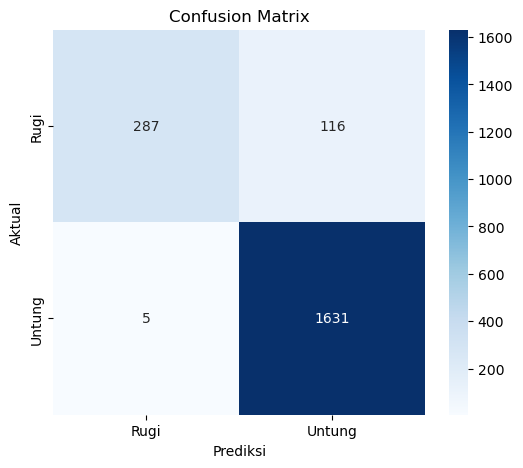

In [16]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rugi", "Untung"],
            yticklabels=["Rugi", "Untung"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## 5. Visualisasi Decision Tree

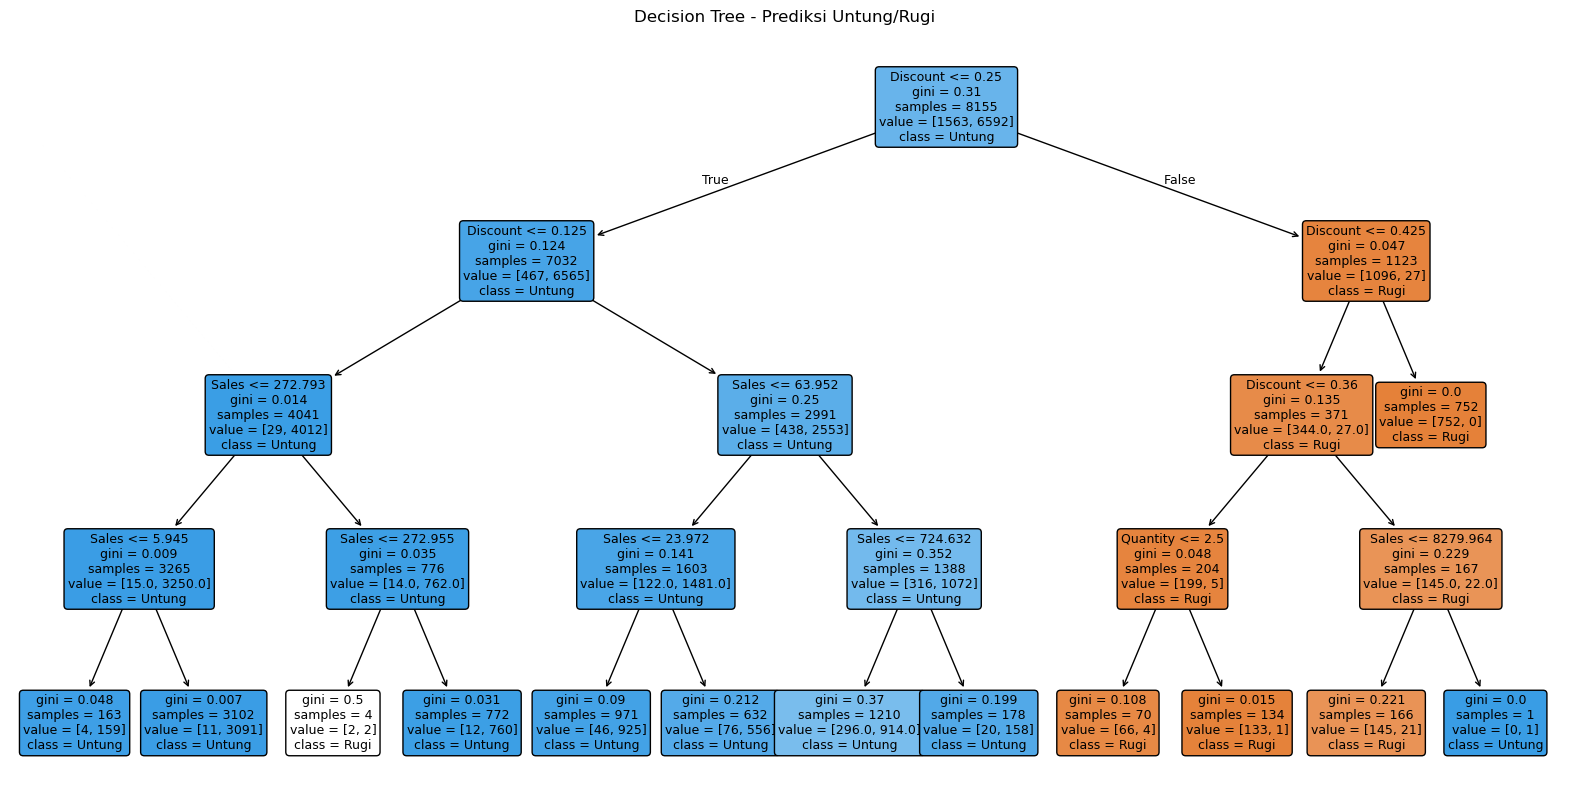

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["Rugi", "Untung"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree - Prediksi Untung/Rugi")
plt.show()

## 6. Kesimpulan

In [24]:
# Feature importance — fitur mana yang paling berpengaruh
importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Tingkat kepentingan fitur:")
print(importance)

print(f"\n{'='*40}")
print(f"Akurasi model: {akurasi*100:.1f}%")
print("Insight: Discount adalah faktor terpenting")
print("dalam menentukan untung/rugi transaksi")
print(f"{'='*40}")

Tingkat kepentingan fitur:
      Fitur  Importance
1  Discount    0.972319
0     Sales    0.027549
2  Quantity    0.000132

Akurasi model: 94.1%
Insight: Discount adalah faktor terpenting
dalam menentukan untung/rugi transaksi
